# EDA

This first step is focused on boiling the corpus down to a digestible format that can be handled by nlp paradigms.



In [38]:
import pandas as pd
import numpy as np
import openai
import re 
import os
import glob
import json
import seaborn as sns
import matplotlib.pyplot as plt
from cleaning_helpers import *

## Loading and Cleaning 

In [39]:
import os
import pandas as pd


def process_all_txt_files(input_dir: str, output_dir: str) -> pd.DataFrame:
    """
    Process all .txt files in `input_dir`:
    1. Clean each file using clean_file
    2. Save cleaned version in output_dir
    3. Process cleaned file into sentences using process_txt_file
    4. Concatenate all results into a single DataFrame
    """
    all_dfs = []

    # Make sure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for filename in os.listdir(input_dir):
        if filename.lower().endswith(".txt"):
            input_path = os.path.join(input_dir, filename)
            cleaned_filename = os.path.splitext(filename)[0] + "_cleaned.txt"
            cleaned_path = os.path.join(output_dir, cleaned_filename)

            # Step 1: Clean the file
            clean_file(input_path, cleaned_path)

            # Step 2: Process cleaned file into sentences
            df = process_txt_file(cleaned_path)

            # Optional: add a column for original file name
            df["source_file"] = filename

            all_dfs.append(df)

    # Step 3: Concatenate all DataFrames
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
    else:
        combined_df = pd.DataFrame(columns=["page", "sentence", "source_file"])

    return combined_df


# Example usage
input_dir = r"C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/"
output_dir = r"C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/"

corpus = process_all_txt_files(input_dir, output_dir)
print(corpus.head(20))


Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak10_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak2_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak3_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak4_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak5_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak6_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak7_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak8_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Divan_Prak9_cleaned.txt
Cleaned file saved as: C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/cleaned/Div

# Studying and Filtering

In [40]:
corpus.head()
corpus.replace('', np.nan, inplace=True)
corpus

,page,sentence,source_file
0,1,Ե 2 - ա -- ---- ----Բ,Divan_Prak10.txt
1,1,4,Divan_Prak10.txt
2,1,"""",Divan_Prak10.txt
3,1,0 4,Divan_Prak10.txt
4,1,"23 """,Divan_Prak10.txt
...,...,...,...
154751,166,վերջերից։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...
154752,166,"Պաշտոնապես գրանցվել է Գերմանիայում 1982 թ., իս...",ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...
154753,166,Նպատակն է իրականացնել ներկայիս Հայաստանի Հանրա...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...
154754,166,ուսումնասիրություններ։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...


## Empty text filtration

### **Cleaning is done here**

<Axes: xlabel='text_length', ylabel='Count'>

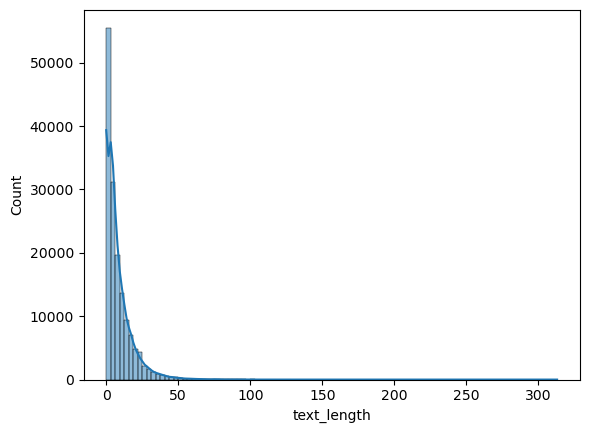

In [41]:
corpus.dropna(subset=['sentence'],inplace=True)
corpus['sentence']=corpus['sentence'].apply(lambda x: clean_text(x))
corpus['text_length']=corpus['sentence'].apply(lambda x: len(x.strip().split()))
sns.histplot(corpus['text_length'],kde=True,bins=100)

In [42]:
corpus.head()

,page,sentence,source_file,text_length
0,1,ե ա բ,Divan_Prak10.txt,3
1,1,,Divan_Prak10.txt,0
2,1,,Divan_Prak10.txt,0
3,1,,Divan_Prak10.txt,0
4,1,,Divan_Prak10.txt,0


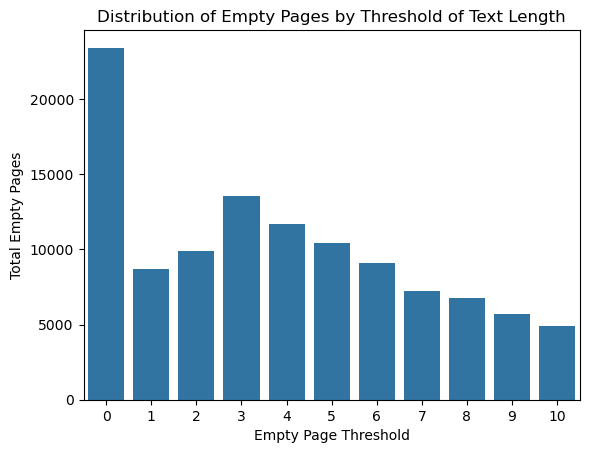

In [43]:
thresholds = range(0, 11)  
empty_pages_counts = []
cumsums=[]

for t in thresholds:
    count = corpus[corpus['text_length'] == t].shape[0]  
    cumsum= corpus[corpus['text_length'] <= t].shape[0]  
    empty_pages_counts.append(count)
    cumsums.append(cumsum)


df_plot = pd.DataFrame({
    'empty_page_threshold': thresholds,
    'total_empty_pages': empty_pages_counts
})


sns.barplot(x='empty_page_threshold', y='total_empty_pages', data=df_plot)
plt.xlabel("Empty Page Threshold")
plt.ylabel("Total Empty Pages")
plt.title("Distribution of Empty Pages by Threshold of Text Length")
plt.show()

Text(0.5, 1.0, 'Distribution of Empty Pages by Threshold of Text Length')

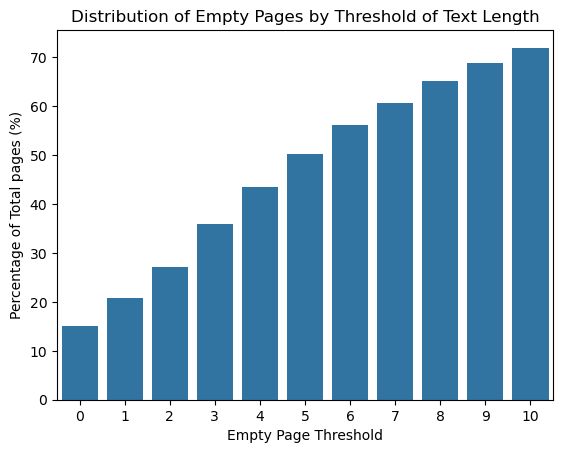

In [44]:
sns.barplot(x=thresholds, y=[(s/len(corpus))*100 for s in cumsums])
plt.xlabel("Empty Page Threshold")
plt.ylabel("Percentage of Total pages (%)")
plt.title("Distribution of Empty Pages by Threshold of Text Length")


Choose 3 as standard emptyness thershold
### Thesholding

In [45]:
empty_pages=corpus[corpus['text_length']<3][['text_length','source_file']].groupby('source_file').count().reset_index().rename(columns={'text_length':'empty_pages'})
corpus=corpus.merge(empty_pages,on='source_file',how='left')
corpus


,page,sentence,source_file,text_length,empty_pages
0,1,ե ա բ,Divan_Prak10.txt,3,803
1,1,,Divan_Prak10.txt,0,803
2,1,,Divan_Prak10.txt,0,803
3,1,,Divan_Prak10.txt,0,803
4,1,,Divan_Prak10.txt,0,803
...,...,...,...,...,...
154751,166,վերջերից։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,1,938
154752,166,պաշտոնապես գրանցվել է գերմանիայում թ իսկ հայաս...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,10,938
154753,166,նպատակն է իրականացնել ներկայիս հայաստանի հանրա...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,19,938
154754,166,ուսումնասիրություններ։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,1,938


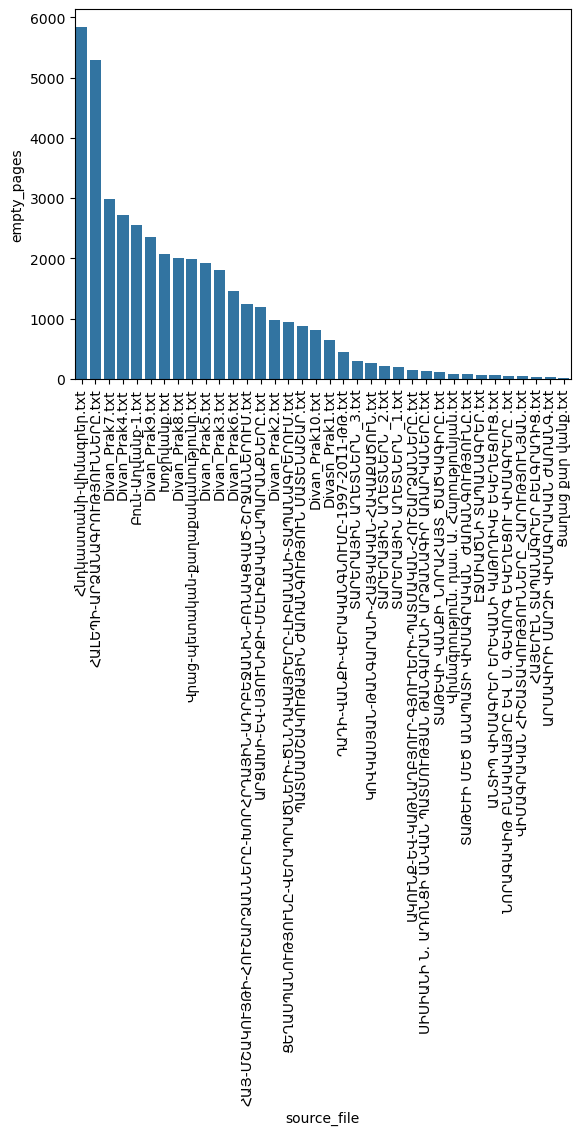

In [46]:
sorted_corpus=corpus[['source_file','empty_pages']].drop_duplicates().sort_values(by='empty_pages',ascending=False)
sns.barplot(x=sorted_corpus['source_file'],y=sorted_corpus['empty_pages'])
plt.xticks(rotation=90)
plt.show()

In [47]:
filtered_corpus=corpus[corpus['text_length']>3]
filtered_corpus

,page,sentence,source_file,text_length,empty_pages
14,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...,Divan_Prak10.txt,11,803
15,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,Divan_Prak10.txt,11,803
16,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,Divan_Prak10.txt,19,803
17,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,Divan_Prak10.txt,8,803
18,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,Divan_Prak10.txt,35,803
...,...,...,...,...,...
154726,163,քէլէշեան մ սիս մատեան պէյրութ ։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,6,938
154727,163,ազդակ մայիս ։ ճայիս ։ ապրիլ ։ ազդակ բացառիկ ։ ...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,35,938
154749,166,հայկական ճարտարապետությունն ուսումնասիրող հճու...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,9,938
154752,166,պաշտոնապես գրանցվել է գերմանիայում թ իսկ հայաս...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,10,938


## Short text filtration

C:\Users\Kamal\AppData\Local\Temp\ipykernel_38156\3745239589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_corpus['max_token_length']=filtered_corpus['sentence'].apply(lambda x: max([len(token) for token in x.split()]))


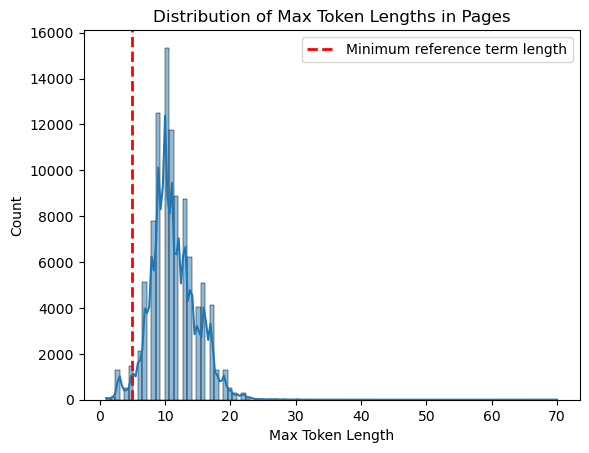

In [48]:
filtered_corpus['max_token_length']=filtered_corpus['sentence'].apply(lambda x: max([len(token) for token in x.split()]))
sns.histplot(filtered_corpus['max_token_length'],kde=True,bins=100)
plt.xlabel('Max Token Length')
plt.title('Distribution of Max Token Lengths in Pages')
plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Minimum reference term length')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Distribution of Reference Term Lengths')

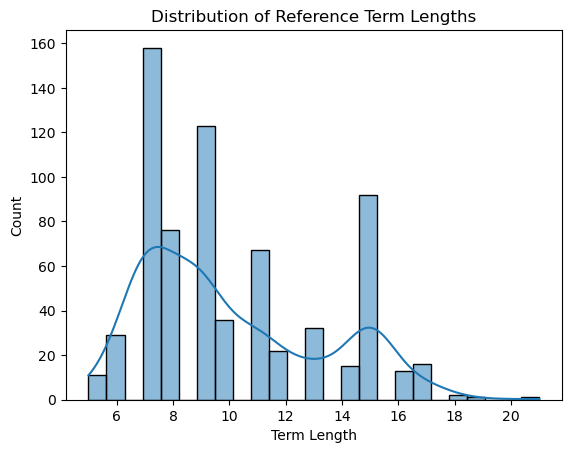

In [49]:
reference_terms=pd.read_excel('C:/Users/Kamal/OneDrive/Desktop/PDS/Copy of corpus_inscription_terms.xlsx',sheet_name='Terms with Examples')
reference_terms.dropna(subset='term',inplace=True)
reference_terms['term_length']=reference_terms['term'].apply(lambda x: max([len(token) for token in x.split()]))
sns.histplot(reference_terms['term_length'],kde=True,bins=25)
plt.xlabel('Term Length')
plt.title('Distribution of Reference Term Lengths')

In [50]:
reference_terms.describe()

,count_in_file,term_length
count,694.000000,694.000000
mean,1.445245,10.047550
std,2.535013,3.212402
min,1.000000,5.000000
25%,1.000000,7.000000
50%,1.000000,9.000000
75%,1.000000,12.000000
max,49.000000,21.000000


Given the distribution of the reference terms' lenghts, let's discard of the pages that have a max token length of 3

In [51]:
filtered_corpus=filtered_corpus[filtered_corpus['max_token_length']>3]
filtered_corpus

,page,sentence,source_file,text_length,empty_pages,max_token_length
14,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...,Divan_Prak10.txt,11,803,12
15,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,Divan_Prak10.txt,11,803,10
16,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,Divan_Prak10.txt,19,803,14
17,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,Divan_Prak10.txt,8,803,13
18,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,Divan_Prak10.txt,35,803,14
...,...,...,...,...,...,...
154726,163,քէլէշեան մ սիս մատեան պէյրութ ։,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,6,938,8
154727,163,ազդակ մայիս ։ ճայիս ։ ապրիլ ։ ազդակ բացառիկ ։ ...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,35,938,11
154749,166,հայկական ճարտարապետությունն ուսումնասիրող հճու...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,9,938,18
154752,166,պաշտոնապես գրանցվել է գերմանիայում թ իսկ հայաս...,ՑԵՂԱՍՊԱՆՈՒԹՅՈՒՆԸ-ՎԵՐԱՊՐԱԾՆԵՐԻ-ԾՆՆԴԱՎԱՅՐԵՐԸ-ԼԻԲ...,10,938,18


In [52]:
filtered_corpus[['source_file','page','sentence']].to_json('filtered_corpus.jsonl',orient='records',lines=True,force_ascii=False)

## Analysis of manual extractions

In [53]:
reference_terms=pd.read_excel('C:/Users/Kamal/OneDrive/Desktop/PDS/Copy of corpus_inscription_terms.xlsx',sheet_name='Terms with Examples')
reference_terms.dropna(subset=['term'],inplace=True) 
reference_terms.drop_duplicates(subset=['term','example'],inplace=True)
reference_terms['term']=reference_terms['term'].apply(lambda x: clean_text(x))
reference_terms.head()

,term,file,count_in_file,example
0,տապանագիր,Divan_Prak10.txt,2,"նք, գերեզմանոց - Լմբատավանք, գերեզմանոց տապան..."
2,սեպագիր,Divan_Prak4.txt,1,"ն րերդշեն, որը գրավել է ուրարտական Ռուսա թագավ..."
3,ալս գլուղում պահպանվել են արձանագրություն,Divan_Prak3.txt,1,ԵՒ ՈՎՍԵՓԱ. ԹՎ. 2։ (1251) Ծանոթ. Գծագիրն ստացե...
4,ալս մատուռի մեջ անցլալում եղել են չորս ձեռագիր,Divan_Prak5.txt,1,"զրին. փոք- րիկ մատուռ է, որի բեմի տակ դամբարան..."
5,ամփոփ տեղեկագիր,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ.txt,2,"., նշվ. աշխ., էջ 310։ 113 Գապպէնճեան Գ., նշվ...."


<Axes: xlabel='term', ylabel='Count'>

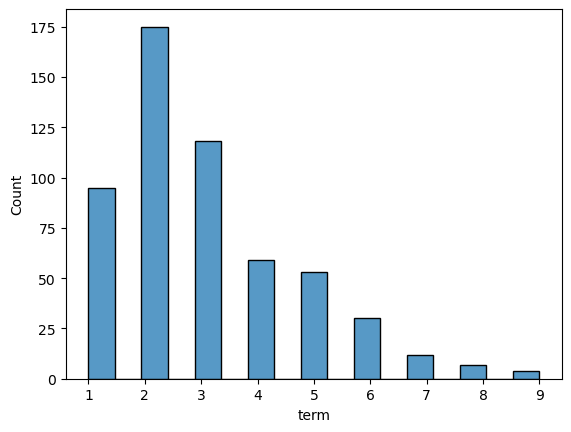

In [54]:
sns.histplot(x=reference_terms['term'].drop_duplicates().apply(lambda x: len(x.split())))

In [55]:
unique_terms=pd.read_excel('C:/Users/Kamal/OneDrive/Desktop/PDS/Copy of corpus_inscription_terms.xlsx',sheet_name='Unique Terms')
unique_terms.drop(columns=['Unnamed: 2'],inplace=True)
unique_terms.dropna(inplace=True)
unique_terms

,term,total_count
0,հիշատակագրություն,83
1,արձանագիր,35
2,հիշատակագիր,30
3,արձանագրություն,26
4,ձեռագիր,26
...,...,...
552,խնդրագիր,1
555,վայելչագիր,1
556,բառ պատուագիր,1
567,ապագիր,1


<Axes: xlabel='term', ylabel='Count'>

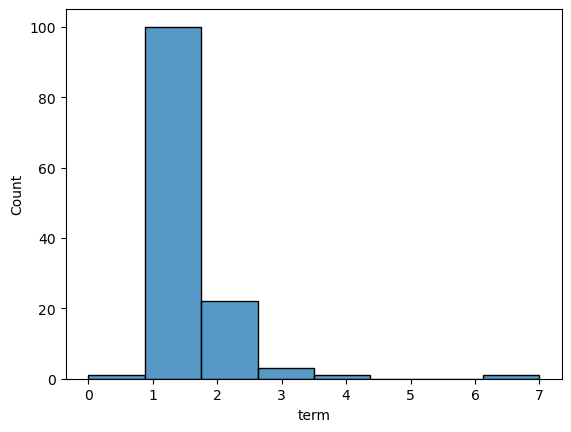

In [56]:
sns.histplot(x=unique_terms['term'].drop_duplicates().apply(lambda x: len(x.split())))

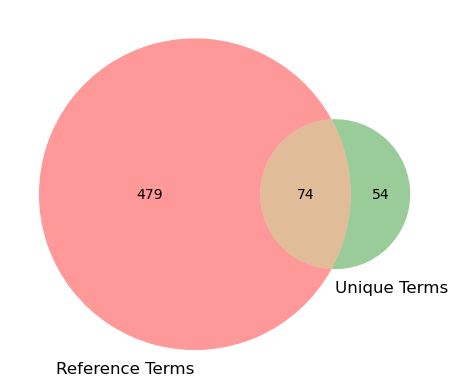

In [57]:
from matplotlib_venn import venn2
set_ref=set(reference_terms['term'])
set_unique=set(unique_terms['term'])
venn2([set_ref, set_unique], set_labels=("Reference Terms", "Unique Terms"))

## Preparation for Divan Prak 10 case study

Extraction is done on ***OpenAI Prototype*** notebook

In [69]:
divan10=pd.read_json('filtered_corpus.jsonl',lines=True)
divan10=divan10[divan10['source_file']=='Divan_Prak10.txt']
divan10['page_number']=divan10['page']
divan10['cleaned_text']=divan10['sentence']
divan10.drop(columns=['page','sentence'],inplace=True)
divan10.head()

,source_file,page_number,cleaned_text
0,Divan_Prak10.txt,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...
1,Divan_Prak10.txt,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...
2,Divan_Prak10.txt,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...
3,Divan_Prak10.txt,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...
4,Divan_Prak10.txt,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...


In [70]:
len(divan10)

1638

In [71]:
import os
import json
import pandas as pd

def load_extractions_from_dir(directory: str) -> pd.DataFrame:
    records = []

    for file in os.listdir(directory):
        if file.endswith(".json"):  # only JSON files
            filepath = os.path.join(directory, file)

            with open(filepath, "r", encoding="utf-8") as f:
                data = json.load(f)  # load full JSON

            # walk through terms → extractions
            for term_entry in data.get("terms", []):
                for occ in term_entry.get("extractions", []):
                    records.append({
                        "dict_term": term_entry.get("term"),
                        "definition": term_entry.get("definition"),
                        "term": occ.get("term"),
                        "context": occ.get("context"),
                        "file_name": occ.get("file_name"),
                        "page_number": occ.get("page_number"),
                        "source_file": file,
                    })

    return pd.DataFrame(records)

# Example usage
divan10_extractions = load_extractions_from_dir("C:/Users/Kamal/OneDrive/Documents/GitHub/dhlab-epigraphy-studies/preprocessing/divan10")
divan10_extractions.drop(columns=["dict_term", "definition"], inplace=True)
divan10_extractions.head()

,term,context,file_name,page_number,source_file
0,վիմագիր,արևելյան նիրակի ներկայիս ... շիրակի մարզ վիմագ...,Divan_Prak10,11,extraction_chunk_1.json
1,վիմագրերը,թվային ծոտոխցիկներով լուսանկարել պրակում լուսա...,Divan_Prak10,12,extraction_chunk_1.json
2,վիմագրերը,տեղում համեմատել վիմագրերը։ 2 ձեռքի տակ ունենա...,Divan_Prak10,12,extraction_chunk_1.json
3,վիմագրերը,եթե խաչի ձորի վիմագրերը թե րևս չէին կարող լինե...,Divan_Prak10,12,extraction_chunk_1.json
4,վիմագրերի,վիմագրերի վերծանության գրեթե հիսնամյա հեռավորո...,Divan_Prak10,11,extraction_chunk_1.json


## Term distribution 

### Special Terms Per Page

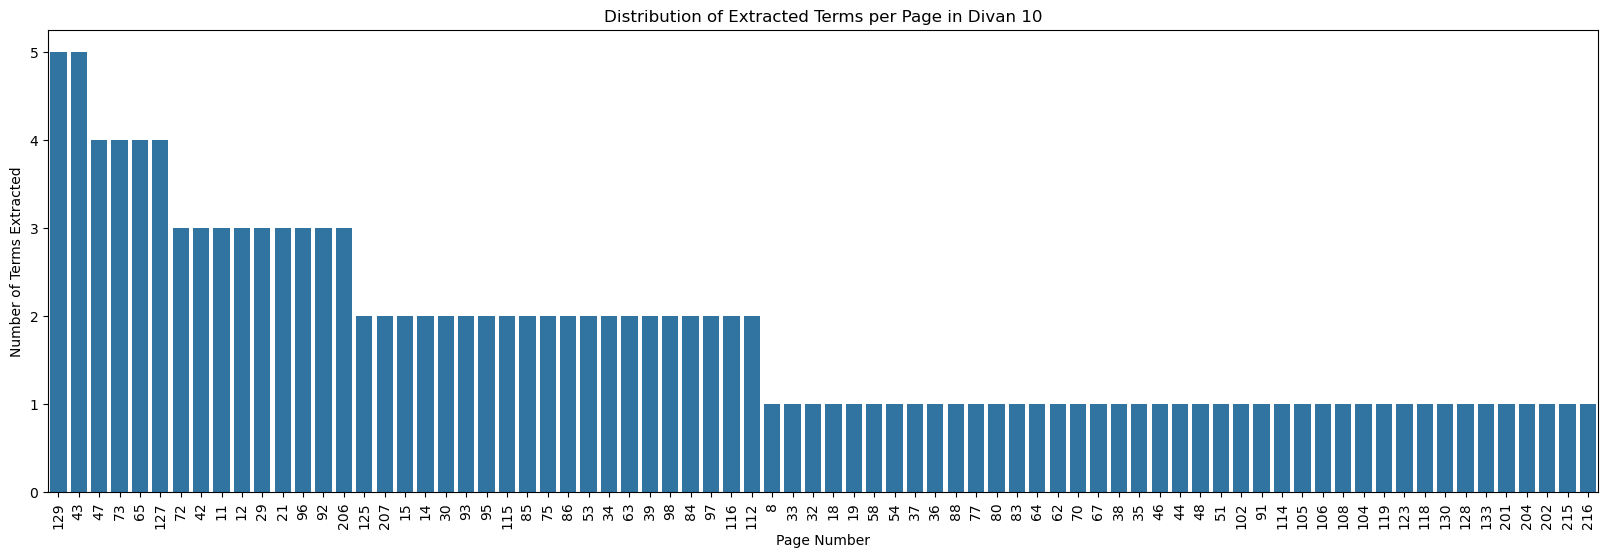

In [72]:
occurences_per_page=divan10_extractions[['page_number','term']].groupby('page_number').count().reset_index().sort_values(by='term',ascending=False)
plt.figure(figsize=(20, 6))
sns.barplot(x=occurences_per_page['page_number'], y=occurences_per_page['term'],order=occurences_per_page["page_number"])
plt.xlabel('Page Number')
plt.ylabel('Number of Terms Extracted')
plt.xticks(rotation=90)
plt.title('Distribution of Extracted Terms per Page in Divan 10')
plt.show()

#### Proportion of Sentece of Interest per page

C:\Users\Kamal\AppData\Local\Temp\ipykernel_38156\3249919368.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ratios['ratio'].fillna(0,inplace=True)


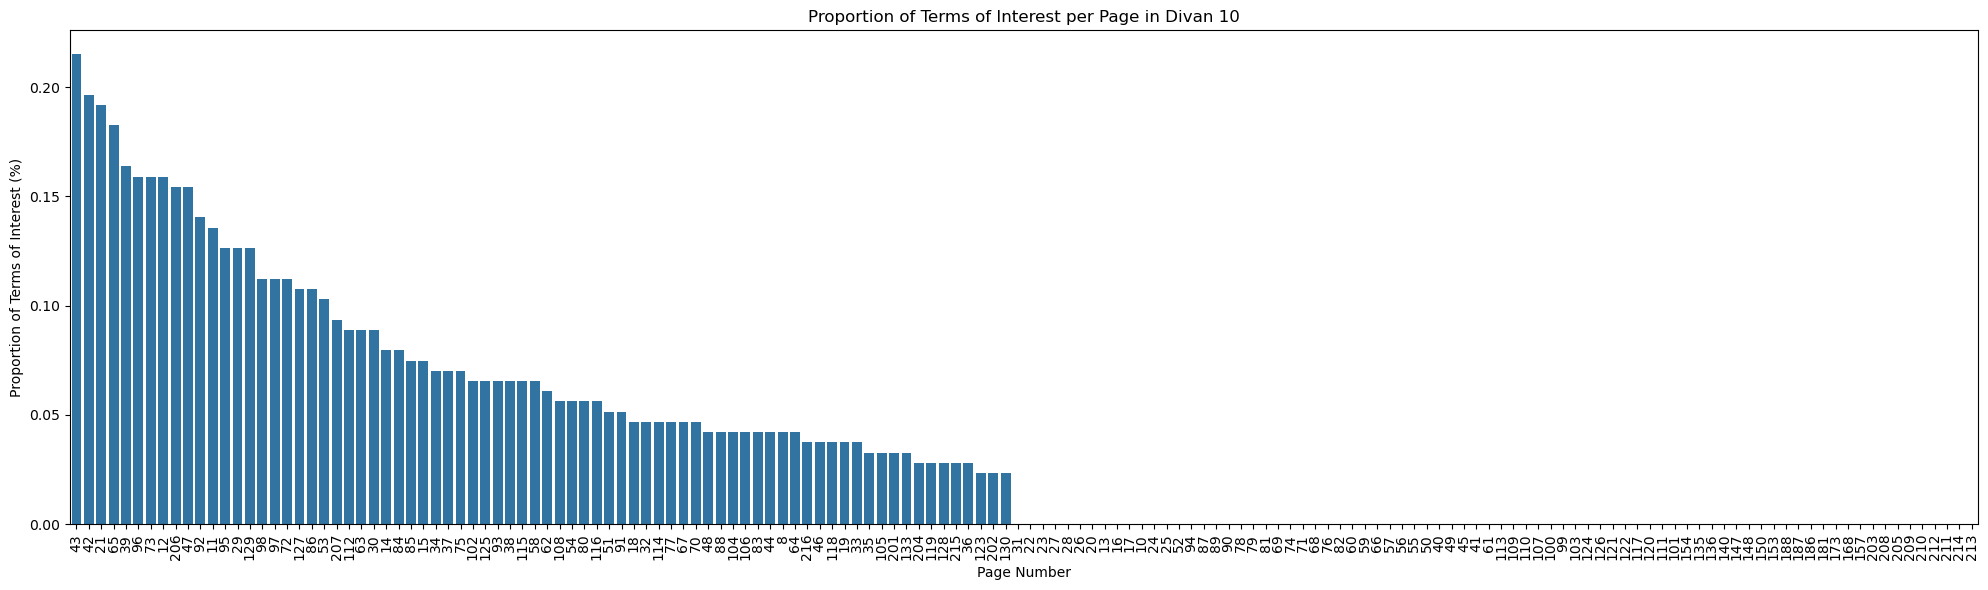

In [73]:
divan10_extractions['context_legth']=divan10_extractions['context'].apply(lambda x: len(x.split()))
interest_per_page=divan10_extractions[['page_number','context_legth']].groupby('page_number').sum().reset_index()



divan10['text_length']=divan10['cleaned_text'].apply(lambda x: len(x.split()))
tokens_per_page=divan10[['page_number','text_length']].groupby('page_number').sum().reset_index()


ratios=pd.merge(interest_per_page,tokens_per_page,on='page_number',how='outer')
ratios['ratio']=(ratios['context_legth']/(ratios['text_length'].sum()))*100
ratios['ratio'].fillna(0,inplace=True)
ratios.sort_values(by='ratio',ascending=False,inplace=True)


plt.figure(figsize=(20, 6))
sns.barplot(x=ratios['page_number'],y=ratios['ratio'],order=ratios['page_number'])
plt.xlabel('Page Number')
plt.xticks(rotation=90)
plt.ylabel('Proportion of Terms of Interest (%)')
plt.title('Proportion of Terms of Interest per Page in Divan 10')
plt.tight_layout()
plt.show()

# Conversion to Trainable Data

In [74]:
df=pd.merge(divan10[['page_number','cleaned_text']],divan10_extractions[['page_number','term','context']],on='page_number',how='outer')
df.head()

,page_number,cleaned_text,term,context
0,8,տպագրվում է հ գաս հնագիտության և ազգագրության ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
1,8,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
2,8,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
3,8,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...
4,8,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...


In [77]:
import pandas as pd
import re
import json
import math

def split_arm_sentence(text):
    """
    Splits a paragraph into sentences using only Armenian full stop (։)
    """
    # Replace line breaks with spaces
    text = text.replace("\n", " ").replace("\r", " ")
    
    # Split by Armenian full stop
    sentences = [s.strip() for s in text.split('։') if s.strip()]
    
    return sentences

dataset = []

for _, row in df.iterrows():
    text = str(row['cleaned_text'])
    sentences = split_arm_sentence(text)
    
    term = row['term']
    context = row['context']
    page_number = row['page_number']

    for sentence in sentences:
        input_text = sentence
        output_entities = []

        if term is not None and not (isinstance(term, float) and math.isnan(term)):
            # Annotate if term or context appears in the sentence
            if str(term) in sentence or (context is not None and str(context) in sentence):
                output_entities.append(f"{term}: type of inscription")

        output_text = ", ".join(output_entities) if output_entities else ""
        dataset.append({"input": input_text, "output": output_text, "page_number": page_number})

# Save to JSONL
with open("sentece_split_test.jsonl", "w", encoding="utf-8") as f:
    for entry in dataset:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print(f"Dataset created! Total rows: {len(dataset)}")


Dataset created! Total rows: 2747


In [78]:
ner_data=pd.read_json('sentece_split_test.jsonl',lines=True)
ner_data.drop_duplicates(inplace=True)
ner_data.head()

,input,output,page_number
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,,8
1,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,,8
2,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,,8
3,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,,8
4,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,,8


## NER Dataset EDA

### Sentece lengths

Text(0.5, 1.0, 'Distribution of Input Sentence Lengths (<=20 tokens)')

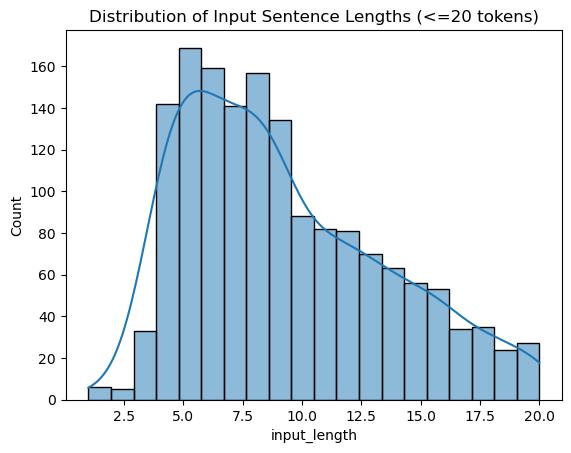

In [79]:
ner_data['input_length']=ner_data['input'].apply(lambda x: len(x.split()))
sns.histplot(ner_data[ner_data['input_length']<=20]['input_length'],kde=True,bins=20)
plt.title('Distribution of Input Sentence Lengths (<=20 tokens)')


Given armenian language, sentences can be two tokens long. We'll remove all sentences that are less than two tokens long

In [85]:
ner_data=ner_data[ner_data['input_length']>2]

### Numeric proportion

In [86]:
import re

def numeric_token_proportion(sentence):
    """
    Calculates the proportion of numerical tokens in a sentence.
    
    Args:
        sentence (str): Input sentence.
    
    Returns:
        float: Proportion of numeric tokens (0 to 1).
    """
    # Split sentence into tokens (words) by whitespace
    tokens = sentence.split()
    
    if not tokens:
        return 0.0  # avoid division by zero for empty sentence
    
    # Count tokens that are numbers (integers or decimals)
    numeric_count = sum(1 for token in tokens if re.fullmatch(r'\d+(\.\d+)?', token))
    
    proportion = numeric_count / len(tokens)
    return proportion


Text(0.5, 1.0, 'Distribution of Numeric Token Proportions in Sentences')

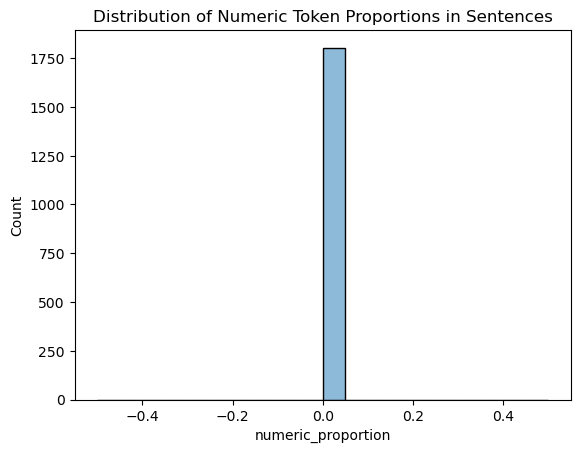

In [87]:
ner_data['numeric_proportion']=ner_data['input'].apply(numeric_token_proportion)
sns.histplot(ner_data['numeric_proportion'],kde=True,bins=20)
plt.title('Distribution of Numeric Token Proportions in Sentences')

In [88]:
filtered_ner_data = ner_data[
    ~(
        (ner_data['output'] == "") & 
        (ner_data['numeric_proportion'] > 0.3)
    )
].reset_index(drop=True)

print(f"Filtered dataset size: {len(filtered_ner_data)}")

Filtered dataset size: 1804


In [89]:
filtered_ner_data

,input,output,page_number,input_length,numeric_proportion
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,,8,11,0.0
1,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,,8,11,0.0
2,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,,8,19,0.0
3,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,,8,8,0.0
4,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,,8,35,0.0
...,...,...,...,...,...
1799,անասուն եզի գութանի սարւած կով ձի ոչխար,,214,7,0.0
1800,սպասք իրեր ձեռագրեր անձինք արծաթեղէն աւետարան ...,,214,23,0.0
1801,անասուն արդիւնք բաժին հոգո ընծա իրեր կիրսն հալ...,,214,11,0.0
1802,էջադրումը և ձևավորումը արթուր հարությունյանի,,216,5,0.0


## Armenian Fraction

Text(0.5, 1.0, 'Distribution of Armenian Token Proportions in Sentences')

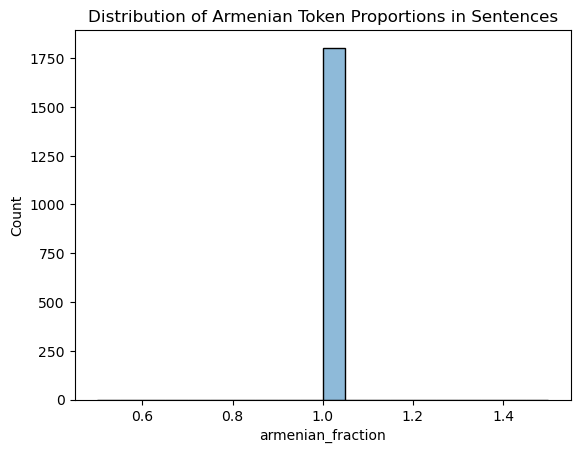

In [90]:
def armenian_fraction(text):
    tokens = text.split()
    if not tokens:
        return 0
    return sum(1 for t in tokens if re.search(r'[\u0530-\u058F]', t)) / len(tokens)

filtered_ner_data['armenian_fraction'] = filtered_ner_data['input'].apply(armenian_fraction)
sns.histplot(filtered_ner_data['armenian_fraction'],kde=True,bins=20)
plt.title('Distribution of Armenian Token Proportions in Sentences')

In [91]:
filtered_ner_data = filtered_ner_data[
    ~(
        (filtered_ner_data['output'] == "") & 
        (filtered_ner_data['armenian_fraction'] <0.60)
    )
].reset_index(drop=True)

filtered_ner_data.count()

input                 1804
output                1804
page_number           1804
input_length          1804
numeric_proportion    1804
armenian_fraction     1804
dtype: int64

In [92]:
filtered_ner_data

,input,output,page_number,input_length,numeric_proportion,armenian_fraction
0,տպագրվում է հ գաս հնագիտության և ազգագրության ...,,8,11,0.0,1.0
1,խմբագրական խորհուրդ՝ գր ս գրիգորյան հ ա մելքոն...,,8,11,0.0,1.0
2,պրակը հրատարակության պատրաստեցին՝ պատմ գիտ թեկ...,,8,19,0.0,1.0
3,պատասխանատու խմբագիրներ՝ գ գ սարգսյան ա է հարո...,,8,8,0.0,1.0
4,դ դիվան հայ վիմագրության պրակ շիրակի մարզ կազմ...,,8,35,0.0,1.0
...,...,...,...,...,...,...
1799,անասուն եզի գութանի սարւած կով ձի ոչխար,,214,7,0.0,1.0
1800,սպասք իրեր ձեռագրեր անձինք արծաթեղէն աւետարան ...,,214,23,0.0,1.0
1801,անասուն արդիւնք բաժին հոգո ընծա իրեր կիրսն հալ...,,214,11,0.0,1.0
1802,էջադրումը և ձևավորումը արթուր հարությունյանի,,216,5,0.0,1.0


### OCR Failsafe

In [93]:
import regex

# Armenian Unicode regex
ARMENIAN_RE = regex.compile(r'[\p{IsArmenian}\p{N}\p{P}]+')


def has_numbers(word: str) -> bool:
    """Check if word contains numbers."""
    return bool(re.search(r'\d', word))

def has_three_repeats(word: str) -> bool:
    """Check if word has ≥3 same Armenian characters in a row."""
    return bool(re.search(r'([\u0530-\u058F])\1{2,}', word))

def has_many_doubles(word: str) -> bool:
    """Check if word has ≥3 double Armenian characters (AA, BB, CC)."""
    doubles = re.findall(r'([\u0530-\u058F])\1', word)
    return len(doubles) >= 3

def has_too_many_non_armenian(word: str) -> bool:
    """Check if word has too many non-Armenian characters."""
    armenian_chars = len(ARMENIAN_RE.findall(word))
    return armenian_chars < len(word) / 2

def has_alternating_pattern(word: str) -> bool:
    """Check if word follows repeating 2-letter Armenian pattern."""
    return bool(re.fullmatch(r'(([\u0530-\u058F]{2})){3,}', word))

def is_suspiciously_short(word: str) -> bool:
    """Check if word is suspiciously short and not valid Armenian."""
    return len(word) <= 2 and not re.fullmatch(r'[\u0530-\u058F]+', word)

def OCR_falacies(word: str) -> bool:
    """
    Detects gibberish Armenian terms based on several heuristic rules.
    """
    checks = [
        has_numbers,
        has_three_repeats,
        has_many_doubles,
        has_too_many_non_armenian,
        has_alternating_pattern,
        is_suspiciously_short,
    ]
    
    return any(check(word) for check in checks)


In [94]:
FALLACY_CHECKS = {
    "has_numbers": has_numbers,
    "has_three_repeats": has_three_repeats,
    "has_many_doubles": has_many_doubles,
    "has_too_many_non_armenian": has_too_many_non_armenian,
    "has_alternating_pattern": has_alternating_pattern,
    "is_suspiciously_short": is_suspiciously_short,
}
def gibberish_fractions(sentence: str) -> dict:
    """
    Computes the fraction of each fallacy type across words in a sentence.
    Returns dict: {fallacy_name: fraction, ..., "overall": fraction}
    """
    # Split into words (keep only alphanumeric + Armenian characters)
    words = re.findall(r'[\u0530-\u058F\dA-Za-z]+', sentence)

    if not words:
        return {name: 0.0 for name in FALLACY_CHECKS} | {"overall": 0.0}

    # Count per fallacy
    results = {name: 0 for name in FALLACY_CHECKS}
    total_words = len(words)

    for w in words:
        for name, fn in FALLACY_CHECKS.items():
            if fn(w):
                results[name] += 1

    # Convert to fractions
    fractions = {name: count / total_words for name, count in results.items()}

    # Overall gibberish = fraction of words flagged by at least one fallacy
    gibberish_count = sum(
        any(fn(w) for fn in FALLACY_CHECKS.values()) for w in words
    )
    fractions["overall"] = gibberish_count / total_words

    return fractions

In [95]:
fractions_df = filtered_ner_data['input'].apply(gibberish_fractions).apply(pd.Series)
fractions_df.head()

,has_numbers,has_three_repeats,has_many_doubles,has_too_many_non_armenian,has_alternating_pattern,is_suspiciously_short,overall
0,0.0,0.0,0.0,0.727273,0.363636,0.0,0.727273
1,0.0,0.0,0.0,0.454545,0.181818,0.0,0.454545
2,0.0,0.0,0.0,0.684211,0.368421,0.0,0.684211
3,0.0,0.0,0.0,0.500000,0.250000,0.0,0.500000
4,0.0,0.0,0.0,0.571429,0.228571,0.0,0.571429


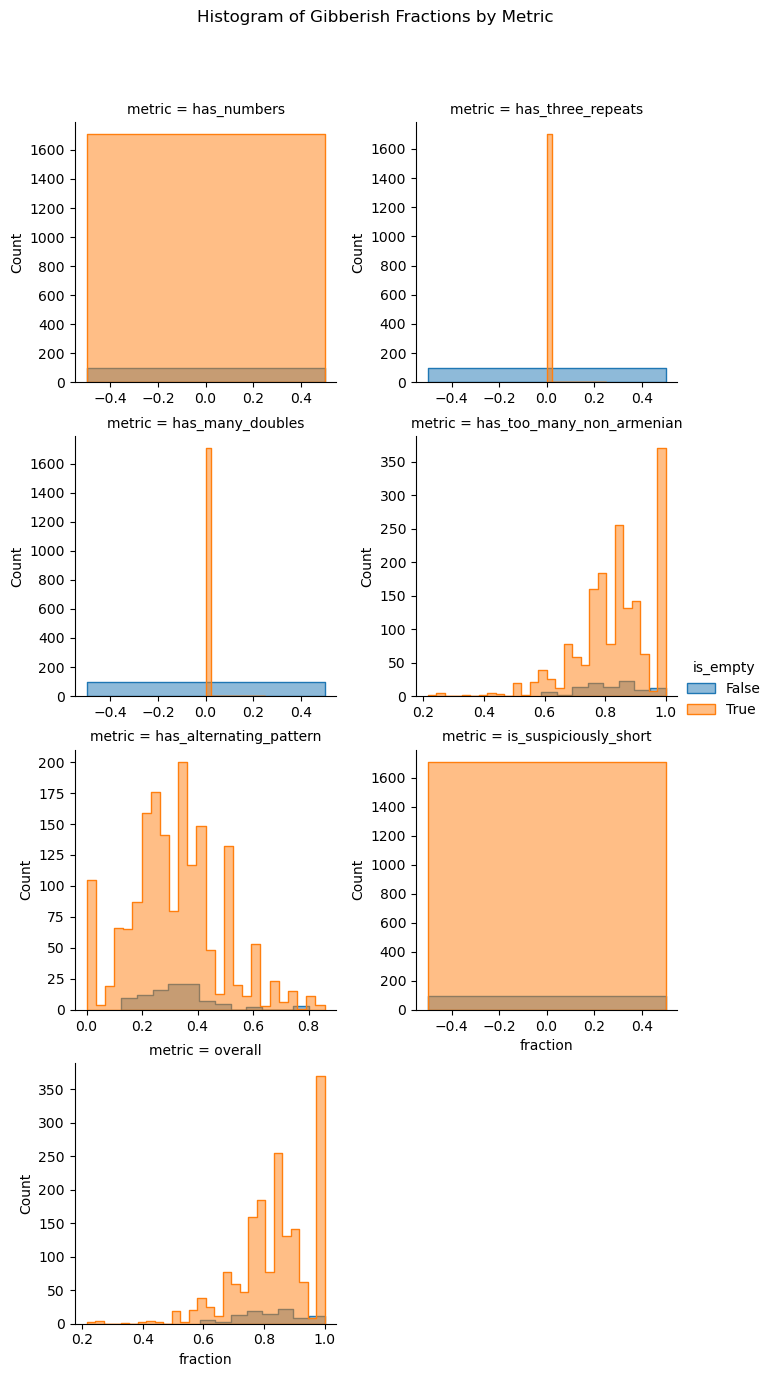

In [96]:
new_ner=filtered_ner_data.copy()
new_ner = new_ner.join(fractions_df)
new_ner['is_empty'] = new_ner['output'].eq("")
melted = new_ner.melt(
    id_vars=['input', 'is_empty'],
    value_vars=list(fractions_df.columns),  # all fallacy metrics
    var_name="metric",
    value_name="fraction"
)

# Plot histograms by metric, with hue on is_empty
g = sns.FacetGrid(melted, col="metric", col_wrap=2, sharex=False, sharey=False, height=3.5,hue='is_empty')
g.map_dataframe(sns.histplot, x="fraction", element="step", multiple="layer",stat="count",alpha=0.5, common_norm=False)
g.add_legend()

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Histogram of Gibberish Fractions by Metric ")
plt.show()

### Cleaning larger Chunks

<Axes: xlabel='input_length', ylabel='Count'>

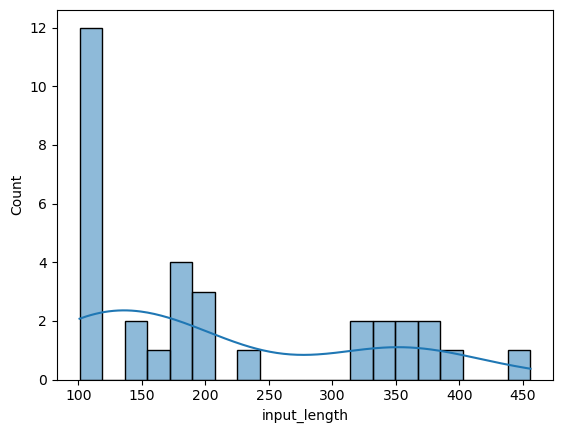

In [60]:
sns.histplot(filtered_ner_data[filtered_ner_data['input_length']>100]['input_length'],kde=True,bins=20)

#### Filter out senteces above 100 words long that do not have any output

In [221]:
filtered_ner_data = filtered_ner_data[
    ~(
        (filtered_ner_data['output'] == "") & 
        (filtered_ner_data['input_length'] >=100)
    )
].reset_index(drop=True)

filtered_ner_data.count()

input                 1274
output                1274
page_number           1274
input_length          1274
numeric_proportion    1274
armenian_fraction     1274
dtype: int64

## reducing long sentences

In [222]:
filtered_ner_data['output_iso']=filtered_ner_data['output'].apply(lambda x: x.split(':')[0] if x else "" )
context=df[['page_number','context','term']]
context.head()

,page_number,context,term
0,6,NaN,NaN
1,7,NaN,NaN
2,8,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները
3,10,NaN,NaN
4,11,արևելյան նիրակի ներկայիս ... շիրակի մարզ վիմագ...,վիմագիր


In [223]:
filtered_with_context=filtered_ner_data.merge(context,right_on=['page_number','term'],left_on=['page_number','output_iso'],how='left')
filtered_with_context

,input,output,page_number,input_length,numeric_proportion,armenian_fraction,output_iso,context,term
0,3 8 աա շօշ շ.. իւ ի շօբթ ստ բ տ 2017,,6,12,0.250000,0.750000,,NaN,NaN
1,797 հհգիտությունների ազգային ակադեմիա հնագիտու...,,7,23,0.086957,0.913043,,NaN,NaN
2,3 դ 391/395( 19)94(479.25) գմդ3.5(57163.359) դ...,,8,80,0.025000,0.912500,,NaN,NaN
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները: type of inscription,8,7,0.000000,1.000000,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները
4,"նախատեսված է պատմա- բանների, վիմագրագետների, հ...",,8,14,0.000000,1.000000,,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1308,"տիգրան գէորգեան-գրիգորեանց, հիշատակվածէ- 27(23...",ապահարկություն: type of inscription,207,117,0.034188,0.717949,ապահարկություն,տուտիկ նվիրատու հառիճավանքի ... ուրտուրիտա ուտ...,ապահարկություն
1309,բովանդակություն հրատարակիչների կողսից պազախնակ...,,215,40,0.125000,0.700000,,NaN,NaN
1310,29 (143) բարճրանեննննննաաեաեա եեաաաա.ցացեաաքաց...,վիմագրերի: type of inscription,215,174,0.109195,0.683908,վիմագրերի,ժամանակագրական աղյուսակ հատորուս ընդգրկվված վի...,վիմագրերի
1311,դիվան հայ վիմագրության պրակ եիրակի սարզ էջադրո...,վիմագրության: type of inscription,216,22,0.181818,0.818182,վիմագրության,դիվան հայ վիմագրության պրակ եիրակի սարզ էջադրո...,վիմագրության


In [45]:
filtered_with_context

NameError: name 'filtered_with_context' is not defined

In [224]:
long_sentences=filtered_with_context[filtered_with_context['input_length']>=70].reset_index(drop=True)
long_sentences['context_legth']=long_sentences['context'].apply(lambda x: len(x.split()) if isinstance(x,str) else 0)

<Axes: xlabel='context_legth', ylabel='Count'>

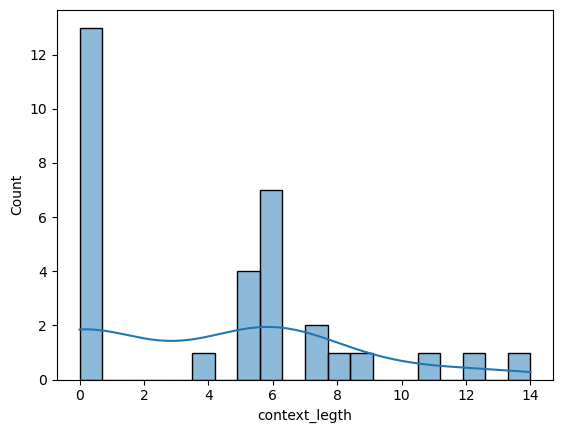

In [225]:
sns.histplot(long_sentences['context_legth'],kde=True,bins=20)

In [226]:
uniform_ner_data=filtered_with_context.copy()

# Condition: input length >= 75 AND context is not null or empty
mask = (uniform_ner_data['input_length'] >= 75) & uniform_ner_data['context'].notnull() & (uniform_ner_data['context'].str.strip() != "")


print(f"Replaced {mask.sum()} long inputs with context.")

uniform_ner_data.loc[mask, 'input'] = uniform_ner_data.loc[mask, 'context']


Replaced 19 long inputs with context.


In [227]:
uniform_ner_data

,input,output,page_number,input_length,numeric_proportion,armenian_fraction,output_iso,context,term
0,3 8 աա շօշ շ.. իւ ի շօբթ ստ բ տ 2017,,6,12,0.250000,0.750000,,NaN,NaN
1,797 հհգիտությունների ազգային ակադեմիա հնագիտու...,,7,23,0.086957,0.913043,,NaN,NaN
2,3 դ 391/395( 19)94(479.25) գմդ3.5(57163.359) դ...,,8,80,0.025000,0.912500,,NaN,NaN
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները: type of inscription,8,7,0.000000,1.000000,վիմական արձանագրությունները,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները
4,"նախատեսված է պատմա- բանների, վիմագրագետների, հ...",,8,14,0.000000,1.000000,,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1308,տուտիկ նվիրատու հառիճավանքի ... ուրտուրիտա ուտ...,ապահարկություն: type of inscription,207,117,0.034188,0.717949,ապահարկություն,տուտիկ նվիրատու հառիճավանքի ... ուրտուրիտա ուտ...,ապահարկություն
1309,բովանդակություն հրատարակիչների կողսից պազախնակ...,,215,40,0.125000,0.700000,,NaN,NaN
1310,ժամանակագրական աղյուսակ հատորուս ընդգրկվված վի...,վիմագրերի: type of inscription,215,174,0.109195,0.683908,վիմագրերի,ժամանակագրական աղյուսակ հատորուս ընդգրկվված վի...,վիմագրերի
1311,դիվան հայ վիմագրության պրակ եիրակի սարզ էջադրո...,վիմագրության: type of inscription,216,22,0.181818,0.818182,վիմագրության,դիվան հայ վիմագրության պրակ եիրակի սարզ էջադրո...,վիմագրության
